In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [16]:
df = pd.read_excel('Survey_For_Prototype_(Responses)_Original.xlsx', sheet_name='Form Responses 1')

In [17]:
df.columns=['timestamp','category','frequency','volume','brand','price',
    'supplier','sustainability','price_10','promo_influence',
    'promo_type','satisfaction','issues','continue',
    'volume_change','name','profession']

In [18]:
sat_map = {'Very dissatisfied': 1, 'Dissatisfied': 2, 'Neutral': 3, 'Satisfied': 4, 'Very satisfied': 5}

In [19]:
continue_map = {'Extremely Unlikely': 1, 'Unlikely': 2, 'Neutral': 3, 'Likely': 4, 'Extremely Likely': 5}

In [20]:
df['satisfaction_num'] = df['satisfaction'].map(sat_map)
df['continue_num'] = df['continue'].map(continue_map)

In [21]:
num_cols = ['brand','price','supplier','sustainability','satisfaction_num','continue_num']


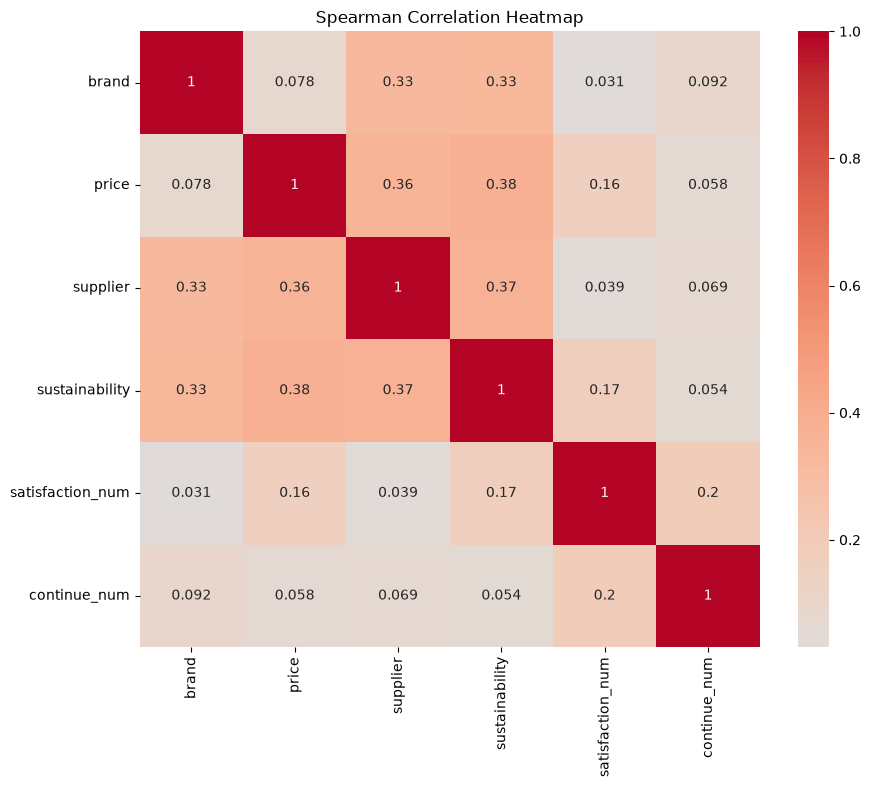

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(method='spearman'), annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Heatmap')
plt.show()

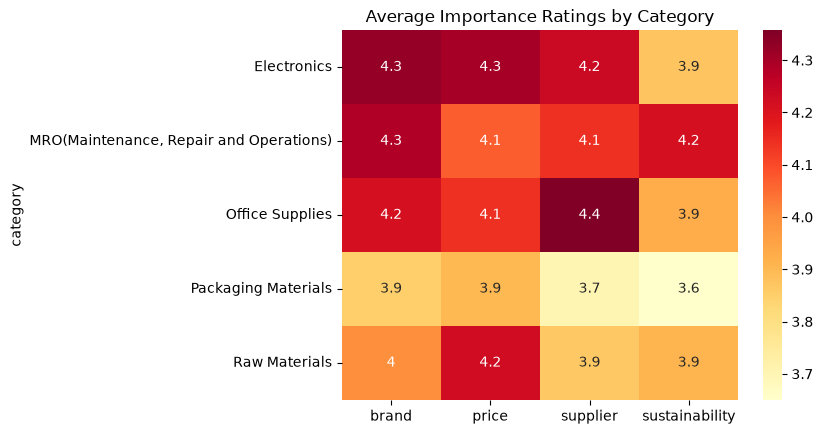

In [24]:
mean_imp = df.groupby('category')[['brand','price','supplier','sustainability']].mean()

sns.heatmap(mean_imp, annot=True, cmap='YlOrRd')
plt.title("Average Importance Ratings by Category")
plt.show()

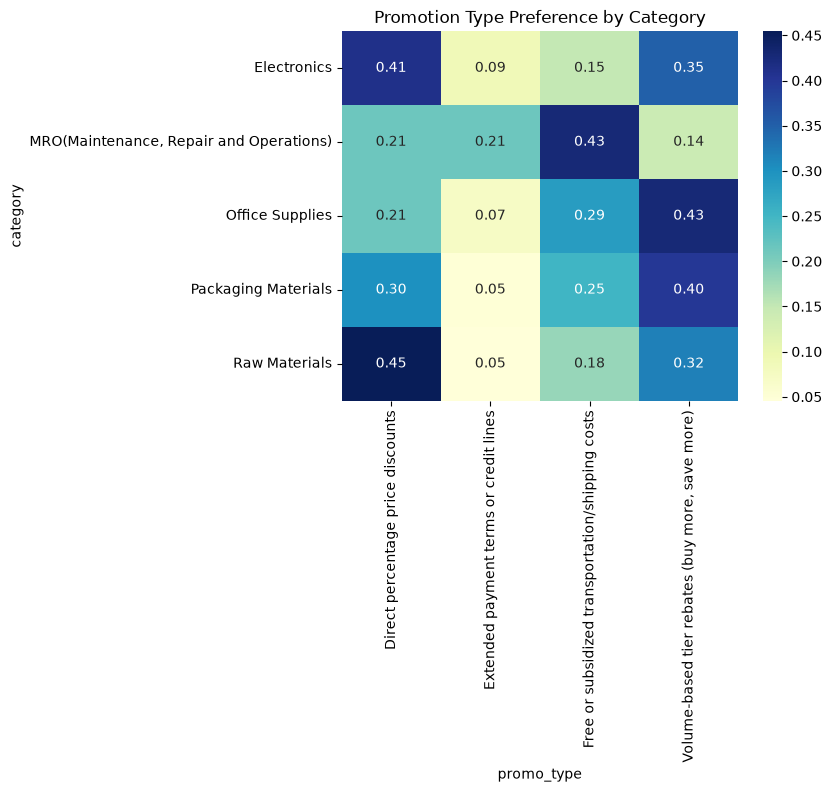

In [31]:
ct = pd.crosstab(df['category'],df['promo_type'],normalize='index')
sns.heatmap(ct,annot=True,cmap='YlGnBu',fmt='.2f')
plt.figsize=(4,4)
plt.title('Promotion Type Preference by Category')
plt.show()

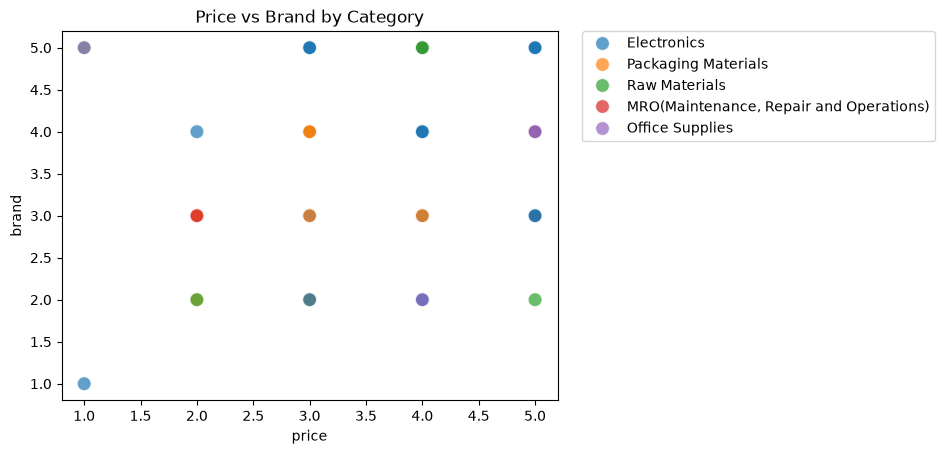

In [39]:
sns.scatterplot(data=df, x='price', y='brand', hue='category', alpha = 0.7, s = 100)
plt.title('Price vs Brand by Category')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

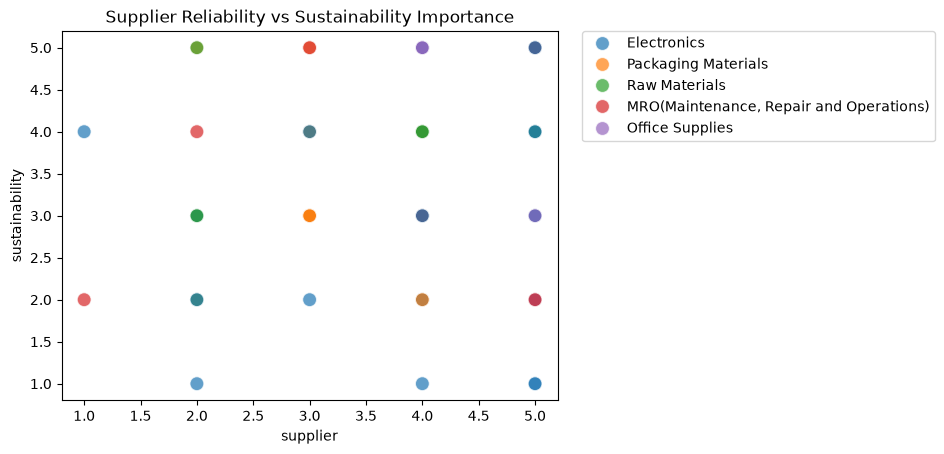

In [41]:
sns.scatterplot(data=df, x='supplier', y='sustainability', hue='category', alpha=0.7, s = 100)
plt.title('Supplier Reliability vs Sustainability Importance')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

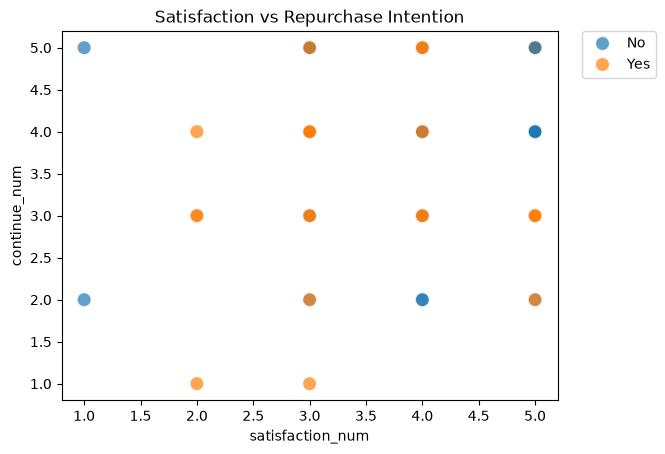

In [43]:
sns.scatterplot(data=df, x='satisfaction_num', y='continue_num', hue='issues',alpha=0.7, s = 100)
plt.title('Satisfaction vs Repurchase Intention')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

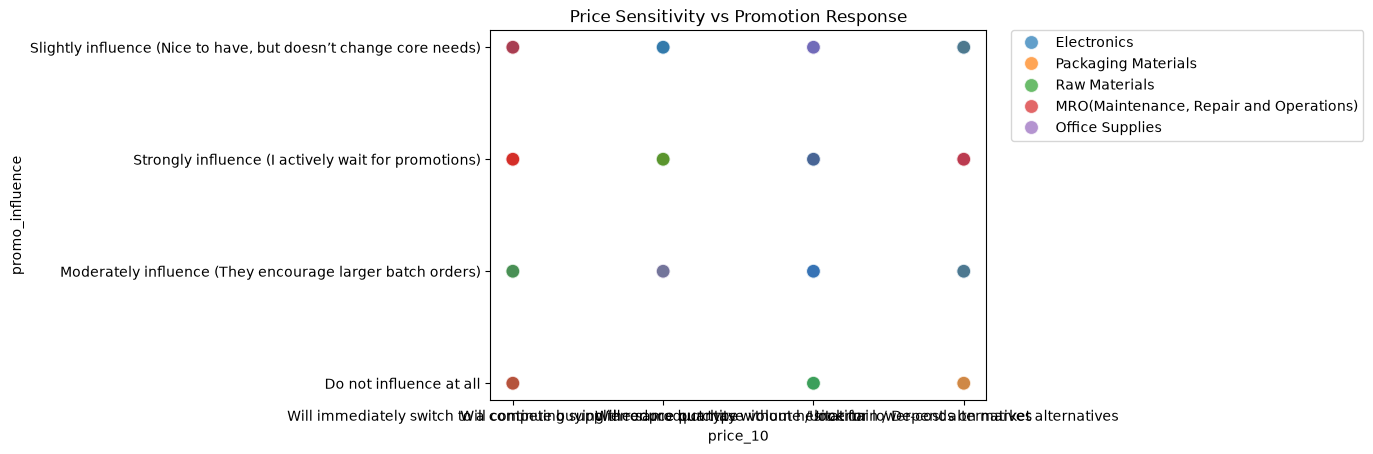

In [50]:
sns.scatterplot(data=df, x='price_10', y='promo_influence', hue='category', alpha=0.7, s = 100)
plt.title('Price Sensitivity vs Promotion Response')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [55]:
chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['category'],df['satisfaction']))

print("Chi2 Statistic: ", chi2)
print("P-value: ", p)
print("Degrees of Freedom: ", dof)
print("Expected Values: \n", expected)

if p < 0.05:
    print("There is a significant relationship between category and satisfaction.")
else:
    print("There is no significant relationship between category and satisfaction.")

Chi2 Statistic:  24.056503841850876
P-value:  0.08827763426720929
Degrees of Freedom:  16
Expected Values: 
 [[ 2.13333333 22.93333333 42.13333333  1.06666667 11.73333333]
 [ 0.37333333  4.01333333  7.37333333  0.18666667  2.05333333]
 [ 0.37333333  4.01333333  7.37333333  0.18666667  2.05333333]
 [ 0.53333333  5.73333333 10.53333333  0.26666667  2.93333333]
 [ 0.58666667  6.30666667 11.58666667  0.29333333  3.22666667]]
There is no significant relationship between category and satisfaction.
